# Data exploring and cleaning

In [1]:
# Dataset 1
import pandas as pd
weekly_housing = pd.read_csv("redfin_weekly_housing_market_data_most_recent.csv")

In [2]:
southeast_states = [
    "Alabama",
    "Arkansas",
    "Florida",
    "Georgia",
    "Kentucky",
    "Louisiana",
    "Mississippi",
    "Missouri",
    "North Carolina",
    "South Carolina",
    "Tennessee",
    "Virginia",
    "West Virginia"
]


southeast_abbreviations = [
    "AL",  # Alabama
    "AR",  # Arkansas
    "FL",  # Florida
    "GA",  # Georgia
    "KY",  # Kentucky
    "LA",  # Louisiana
    "MS",  # Mississippi
    "MO",  # Missouri
    "NC",  # North Carolina
    "SC",  # South Carolina
    "TN",  # Tennessee
    "VA",  # Virginia
    "WV"   # West Virginia
]

In [3]:
se_mapping = dict(zip(southeast_abbreviations, southeast_states))

In [4]:
# Filter the dataset to only include 'county' records
weekly_housing = weekly_housing[weekly_housing['REGION_TYPE']=='county']
weekly_housing['STATE'] = weekly_housing['REGION_NAME'].str.extract(r', \s*([A-Z]{2})')
weekly_housing = weekly_housing[weekly_housing['STATE'].isin(southeast_abbreviations)]

In [5]:
# Clean up explicit county/city spelling anomalies where the housing data conflicts with Census standards
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('La Salle Parish, LA','LaSalle Parish,LA')
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('King & Queen County, VA','King and Queen County,VA')
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('St. Louis City County, MO','St. Louis city,MO')
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('Roanoke City County, VA','Roanoke city,VA')
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('Fairfax City County, VA','Fairfax city,VA')
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('Richmond City County, VA','Richmond city,VA')
weekly_housing['REGION_NAME'] = weekly_housing['REGION_NAME'].str.replace('Franklin City County, VA','Franklin County,VA')

In [6]:
weekly_housing['match_key'] = weekly_housing['REGION_NAME'].apply(
    lambda x: f"{x.split(',')[0]}, {se_mapping[x.split(',')[1].strip()]}")

In [7]:
# State of Virginia has a weird formatting where it has County/City in the dataset.
weekly_housing['match_key'] = weekly_housing['match_key'].str.replace(
    r'\s+(?:[cC]ounty|[cC]ity),\s+Virginia$',
    ', Virginia', regex=True)

In [8]:
# This dataset uses rolling 4-week windows methodology. Because consecutive rows within a month share overlapping 
# observation periods, therefore, I take the last row per county-month as the end-of-month snapshot, 
# which best represents the 4-week window closest to the calendar month end.

weekly_housing = weekly_housing[weekly_housing['DURATION'] == '4 weeks']

According to Redfin's website, theirs weekly observations are based on rolling 4-week windows, so weekly observations within the same calendar month are not independent. To avoid double-counting overlapping periods, the final weekly observation of each county-month was retained as the representative monthly snapshot.

In [9]:
weekly_housing['YEAR_MONTH'] = pd.to_datetime(weekly_housing['PERIOD_END']).dt.to_period('M')

In [10]:
monthly = (
    weekly_housing
    .sort_values(['REGION_NAME', 'PERIOD_END'])
    .groupby(['REGION_NAME', 'REGION_ID', 'YEAR_MONTH'])
    .last()
    .reset_index()
)

In [11]:
#Dataset 2
# This dataset is mainly used for getting county codes for the dataset above.
county_zipcode = pd.read_excel("US Counties.xlsx")
county_zipcode.head()

,FIPS State and County Codes,Geographic area name,RAE Report Links
0,1,Alabama,https://cbb.census.gov/rae/#industry0=00&geoId...
1,1001,"Autauga County, Alabama",https://cbb.census.gov/rae/#industry0=00&geoId...
2,1003,"Baldwin County, Alabama",https://cbb.census.gov/rae/#industry0=00&geoId...
3,1005,"Barbour County, Alabama",https://cbb.census.gov/rae/#industry0=00&geoId...
4,1007,"Bibb County, Alabama",https://cbb.census.gov/rae/#industry0=00&geoId...


In [12]:
county_zipcode = county_zipcode[['FIPS State and County Codes','Geographic area name']]

In [13]:
# To make sure the state of Virginia has the same formatting as it does in the dataset above.
county_zipcode['Geographic area name'] = county_zipcode['Geographic area name'].str.replace(
    r'\s+(?:[cC]ounty|[cC]ity),\s+Virginia$',
    ', Virginia',
    regex=True)

In [14]:
df = pd.merge(monthly, county_zipcode, left_on ='match_key', right_on = 'Geographic area name', how='left')

In [15]:
#Dataset 3
county = pd.read_csv("realtor_Inventory_Hotness_Metrics_County_History.csv")
county.head()

,month_date_yyyymm,county_fips,county_name,cbsa_code,cbsa_title,hh_rank,hotness_rank,hotness_rank_mm,hotness_rank_yy,hotness_score,...,median_dom_yy_day,median_dom_vs_us,page_view_count_per_property_mm,page_view_count_per_property_yy,page_view_count_per_property_vs_us,median_listing_price,median_listing_price_mm,median_listing_price_yy,median_listing_price_vs_us,quality_flag
0,202603,25009,"essex, ma",14460.0,"Boston-Cambridge-Newton, MA-NH",81,1,1,0.0,99.350248,...,4.50,-34.50,0.010155,-0.216805,3.458432,727400.0,0.011683,-0.030069,1.750873,0
1,202603,17203,"woodford, il",37900.0,"Peoria, IL",1267,2,2,-79.0,99.009901,...,-13.75,-30.25,0.332155,0.201790,4.415149,263625.0,0.098554,0.302173,0.634553,0
2,202603,34027,"morris, nj",35620.0,"New York-Newark-Jersey City, NY-NJ",145,3,3,-4.0,98.607673,...,3.00,-32.00,0.036023,-0.076734,3.374666,699725.0,0.024150,-0.000250,1.684258,0
3,202603,36055,"monroe, ny",40380.0,"Rochester, NY",80,4,4,-1.0,97.648515,...,-2.00,-32.50,-0.100805,-0.258372,2.965859,284999.5,0.000349,0.140226,0.686002,0
4,202603,25013,"hampden, ma",44140.0,"Springfield, MA",157,5,5,-4.0,97.555693,...,1.00,-25.00,0.098548,-0.107108,3.644537,352475.0,0.007323,0.068430,0.848417,0


In [16]:
county['state'] = county['county_name'].str.split().str[-1].str.upper()
county['county'] = county['county_name'].str.split(',').str[0].str.capitalize()
county['YEAR_MONTH_C'] = pd.to_datetime(county['month_date_yyyymm'], format = '%Y%m').dt.to_period('M')
county = county[county['state'].isin(southeast_abbreviations)]
county_hotness = county[['YEAR_MONTH_C','county_fips','county','state','hotness_score','demand_score','supply_score']]

In [17]:
df['FIPS State and County Codes'] = df['FIPS State and County Codes'].astype(str).str.zfill(5)
county_hotness['county_fips'] = county_hotness['county_fips'].astype(float).astype(int).astype(str).str.zfill(5)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7592\4063475921.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_hotness['county_fips'] = county_hotness['county_fips'].astype(float).astype(int).astype(str).str.zfill(5)


In [18]:
final_df = pd.merge(
    df, 
    county_hotness, 
    left_on=['FIPS State and County Codes', 'YEAR_MONTH'], 
    right_on=['county_fips', 'YEAR_MONTH_C'], 
    how='left')

In [19]:
cols_to_drop = [
    'Unnamed: 0',
    'REGION_TYPE',
    'REGION_TYPE_ID', 
    'DURATION',
    'LAST_UPDATED',
    'YEAR_MONTH_C',
    'county_fips',
    'county',
    'state',
    'Geographic area name',
    'OFF_MARKET_IN_TWO_WEEKS_YOY',
    'PERCENT_ACTIVE_LISTINGS_WITH_PRICE_DROPS',
    'PERCENT_ACTIVE_LISTINGS_WITH_PRICE_DROPS_YOY'
]

df_clean = final_df.drop(columns=[c for c in cols_to_drop if c in final_df.columns])

In [20]:
#Dataset 4
# Median household income from ACS 2024 5-year estimates, used as a static county socioeconomic characteristic.
income = pd.read_csv('ACSST5Y2024.S1903-Data.csv')

In [21]:
income.head()

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M,Unnamed: 242
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,NaN
1,0500000US01001,"Autauga County, Alabama",22917,435,16939,408,4229,292,6,11,...,2677,47805,3935,46589,7832,43498,4880,91636,13964,NaN
2,0500000US01003,"Baldwin County, Alabama",98574,1224,84273,1336,7675,556,275,117,...,3047,70152,30287,47694,8790,42973,4654,87848,4264,NaN
3,0500000US01005,"Barbour County, Alabama",9128,308,4469,229,4060,228,20,27,...,2981,53182,16312,24962,7665,25268,7749,-,**,NaN
4,0500000US01007,"Bibb County, Alabama",7704,283,5958,292,1481,230,55,44,...,4660,34293,34269,29363,4987,28968,4157,37659,17043,NaN


In [22]:
income = income[['GEO_ID','NAME','S1903_C03_001E']]

In [23]:
income = income.iloc[1:]

In [24]:
# extract the last 5 county code
income['zip'] = income['GEO_ID'].str[-5:]

In [25]:
# Split by comma and expand, then strip any accidental trailing/leading spaces
income['State'] = income['NAME'].str.split(',', expand=True)[1].str.strip()

In [26]:
income_SE = income[income['State'].isin(southeast_states)].reset_index(drop=True)

In [27]:
income_SE = income_SE.rename(columns={'S1903_C03_001E':'Income'})

In [28]:
income_SE

,GEO_ID,NAME,Income,zip,State
0,0500000US01001,"Autauga County, Alabama",72481,01001,Alabama
1,0500000US01003,"Baldwin County, Alabama",78775,01003,Alabama
2,0500000US01005,"Barbour County, Alabama",46042,01005,Alabama
3,0500000US01007,"Bibb County, Alabama",52541,01007,Alabama
4,0500000US01009,"Blount County, Alabama",64190,01009,Alabama
...,...,...,...,...,...
1173,0500000US54101,"Webster County, West Virginia",43839,54101,West Virginia
1174,0500000US54103,"Wetzel County, West Virginia",56836,54103,West Virginia
1175,0500000US54105,"Wirt County, West Virginia",49867,54105,West Virginia
1176,0500000US54107,"Wood County, West Virginia",57810,54107,West Virginia


In [29]:
#Dataset 5
# population count from 2020-2025
population = pd.read_excel('co-est2025-pop.xlsx')

In [30]:
population

,table with row headers in column A and column headers in rows 3 through 4 (leading dots indicate sub-parts),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Annual Estimates of the Resident Population fo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geographic Area,"April 1, 2020 Estimates Base",Population Estimate (as of July 1),NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2020,2021.0,2022.0,2023.0,2024.0,2025.0
3,United States,331516113,331578104,332100166.0,333996304.0,336755052.0,340003797.0,341784857.0
4,".Autauga County, Alabama",58805,58914,59207.0,59755.0,60502.0,61476.0,61920.0
...,...,...,...,...,...,...,...,...
3149,The estimates are based on the 2020 Modified A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3150,Suggested Citation:,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3151,Annual Estimates of the Resident Population fo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3152,"Source: U.S. Census Bureau, Population Division",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
population_clean = population.iloc[2:3148].copy()
population_clean.columns = ['Geography_Name', 'Drop_Base', '2020', '2021', '2022', '2023', '2024', '2025']
population_clean = population_clean.drop([2, 3])
population_clean = population_clean.drop(columns=['Drop_Base'])

In [32]:
population_clean

,Geography_Name,2020,2021,2022,2023,2024,2025
4,".Autauga County, Alabama",58914,59207.0,59755.0,60502.0,61476.0,61920.0
5,".Baldwin County, Alabama",233252,239450.0,246703.0,254193.0,261652.0,267761.0
6,".Barbour County, Alabama",24958,24510.0,24744.0,24681.0,24520.0,24607.0
7,".Bibb County, Alabama",22181,22346.0,21976.0,21881.0,22225.0,22262.0
8,".Blount County, Alabama",59099,59036.0,59450.0,59771.0,60173.0,60156.0
...,...,...,...,...,...,...,...
3143,".Sweetwater County, Wyoming",42194,41636.0,41319.0,41294.0,41350.0,41267.0
3144,".Teton County, Wyoming",23381,23607.0,23324.0,23354.0,23345.0,23333.0
3145,".Uinta County, Wyoming",20462,20691.0,20715.0,20693.0,20653.0,20728.0
3146,".Washakie County, Wyoming",7659,7723.0,7738.0,7731.0,7637.0,7597.0


In [33]:
population_clean['Geography_Name'] = population_clean['Geography_Name'].str.replace('.','')

In [34]:
population_clean['population_state'] = population_clean['Geography_Name'].str.split(',').str[1].str.strip()

In [35]:
population_clean = population_clean[population_clean['population_state'].isin(southeast_states)]
population_clean

,Geography_Name,2020,2021,2022,2023,2024,2025,population_state
4,"Autauga County, Alabama",58914,59207.0,59755.0,60502.0,61476.0,61920.0,Alabama
5,"Baldwin County, Alabama",233252,239450.0,246703.0,254193.0,261652.0,267761.0,Alabama
6,"Barbour County, Alabama",24958,24510.0,24744.0,24681.0,24520.0,24607.0,Alabama
7,"Bibb County, Alabama",22181,22346.0,21976.0,21881.0,22225.0,22262.0,Alabama
8,"Blount County, Alabama",59099,59036.0,59450.0,59771.0,60173.0,60156.0,Alabama
...,...,...,...,...,...,...,...,...
3048,"Webster County, West Virginia",8354,8273.0,8127.0,8032.0,7933.0,7760.0,West Virginia
3049,"Wetzel County, West Virginia",14404,14206.0,14012.0,13993.0,13812.0,13734.0,West Virginia
3050,"Wirt County, West Virginia",5187,5067.0,5097.0,4966.0,4908.0,4879.0,West Virginia
3051,"Wood County, West Virginia",84153,83841.0,83375.0,83015.0,82650.0,82385.0,West Virginia


In [36]:
income_SE

,GEO_ID,NAME,Income,zip,State
0,0500000US01001,"Autauga County, Alabama",72481,01001,Alabama
1,0500000US01003,"Baldwin County, Alabama",78775,01003,Alabama
2,0500000US01005,"Barbour County, Alabama",46042,01005,Alabama
3,0500000US01007,"Bibb County, Alabama",52541,01007,Alabama
4,0500000US01009,"Blount County, Alabama",64190,01009,Alabama
...,...,...,...,...,...
1173,0500000US54101,"Webster County, West Virginia",43839,54101,West Virginia
1174,0500000US54103,"Wetzel County, West Virginia",56836,54103,West Virginia
1175,0500000US54105,"Wirt County, West Virginia",49867,54105,West Virginia
1176,0500000US54107,"Wood County, West Virginia",57810,54107,West Virginia


In [37]:
# Found these are not standard, active county FIPS codes after debugging
target_codes = [
    '51515', '22087', '29183', '22089', '01115', '29185', '05123', '29187', 
    '22093', '22095', '12109', '22097', '29189', '29510', '12111', '22099', 
    '22101', '22103', '29186'
]


# Keep only the rows where the FIPS code is NOT in the target_codes list
# dropped approximately 1.2k rows
df_clean = df_clean[~df_clean['FIPS State and County Codes'].isin(target_codes)].copy()

In [38]:
population_clean_df = pd.merge(income_SE[['NAME','zip']], population_clean, left_on='NAME', right_on='Geography_Name', how='inner')

In [39]:
# Convert from wide (one column per year) to long (one row per year)
population_clean_df = population_clean_df.melt(
    id_vars=['zip', 'Geography_Name'],
    value_vars=['2020', '2021', '2022', '2023', '2024', '2025'],
    var_name='year',
    value_name='population')

population_clean_df['year'] = population_clean_df['year'].astype(int)

In [40]:
population_clean_df

,zip,Geography_Name,year,population
0,01001,"Autauga County, Alabama",2020,58914
1,01003,"Baldwin County, Alabama",2020,233252
2,01005,"Barbour County, Alabama",2020,24958
3,01007,"Bibb County, Alabama",2020,22181
4,01009,"Blount County, Alabama",2020,59099
...,...,...,...,...
6949,54101,"Webster County, West Virginia",2025,7760.0
6950,54103,"Wetzel County, West Virginia",2025,13734.0
6951,54105,"Wirt County, West Virginia",2025,4879.0
6952,54107,"Wood County, West Virginia",2025,82385.0


In [41]:
df_clean['year'] = df_clean['YEAR_MONTH'].astype(str).str[:4].astype(int)

In [42]:
df_population = pd.merge(
    df_clean,
    population_clean_df[['zip', 'year', 'population']],
    left_on=['FIPS State and County Codes', 'year'],
    right_on=['zip','year'],
    how='left')


In [43]:
df_all = pd.merge(df_population,income_SE[['zip','Income']], left_on='FIPS State and County Codes', right_on = 'zip', how='left')

In [44]:
df_all.columns

Index(['REGION_NAME', 'REGION_ID', 'YEAR_MONTH', 'PERIOD_BEGIN', 'PERIOD_END',
       'ADJUSTED_AVERAGE_NEW_LISTINGS', 'ADJUSTED_AVERAGE_NEW_LISTINGS_YOY',
       'AVERAGE_PENDING_SALES_LISTING_UPDATES',
       'AVERAGE_PENDING_SALES_LISTING_UPDATES_YOY', 'OFF_MARKET_IN_TWO_WEEKS',
       'ADJUSTED_AVERAGE_HOMES_SOLD', 'ADJUSTED_AVERAGE_HOMES_SOLD_YOY',
       'MEDIAN_NEW_LISTING_PRICE', 'MEDIAN_NEW_LISTING_PRICE_YOY',
       'MEDIAN_SALE_PRICE', 'MEDIAN_SALE_PRICE_YOY', 'MEDIAN_DAYS_TO_CLOSE',
       'MEDIAN_DAYS_TO_CLOSE_YOY', 'MEDIAN_NEW_LISTING_PPSF',
       'MEDIAN_NEW_LISTING_PPSF_YOY', 'ACTIVE_LISTINGS', 'ACTIVE_LISTINGS_YOY',
       'MEDIAN_DAYS_ON_MARKET', 'MEDIAN_DAYS_ON_MARKET_YOY',
       'AGE_OF_INVENTORY', 'AGE_OF_INVENTORY_YOY', 'WEEKS_OF_SUPPLY',
       'WEEKS_OF_SUPPLY_YOY', 'MEDIAN_PENDING_SQFT', 'MEDIAN_PENDING_SQFT_YOY',
       'AVERAGE_SALE_TO_LIST_RATIO', 'AVERAGE_SALE_TO_LIST_RATIO_YOY',
       'MEDIAN_SALE_PPSF', 'MEDIAN_SALE_PPSF_YOY', 'STATE', 'match_key',
   

In [45]:
df_all = df_all.drop(['zip_y','zip_x','match_key',],axis=1)

In [46]:
pd.set_option('display.max_columns', None)
df_all.head()

,REGION_NAME,REGION_ID,YEAR_MONTH,PERIOD_BEGIN,PERIOD_END,ADJUSTED_AVERAGE_NEW_LISTINGS,ADJUSTED_AVERAGE_NEW_LISTINGS_YOY,AVERAGE_PENDING_SALES_LISTING_UPDATES,AVERAGE_PENDING_SALES_LISTING_UPDATES_YOY,OFF_MARKET_IN_TWO_WEEKS,ADJUSTED_AVERAGE_HOMES_SOLD,ADJUSTED_AVERAGE_HOMES_SOLD_YOY,MEDIAN_NEW_LISTING_PRICE,MEDIAN_NEW_LISTING_PRICE_YOY,MEDIAN_SALE_PRICE,MEDIAN_SALE_PRICE_YOY,MEDIAN_DAYS_TO_CLOSE,MEDIAN_DAYS_TO_CLOSE_YOY,MEDIAN_NEW_LISTING_PPSF,MEDIAN_NEW_LISTING_PPSF_YOY,ACTIVE_LISTINGS,ACTIVE_LISTINGS_YOY,MEDIAN_DAYS_ON_MARKET,MEDIAN_DAYS_ON_MARKET_YOY,AGE_OF_INVENTORY,AGE_OF_INVENTORY_YOY,WEEKS_OF_SUPPLY,WEEKS_OF_SUPPLY_YOY,MEDIAN_PENDING_SQFT,MEDIAN_PENDING_SQFT_YOY,AVERAGE_SALE_TO_LIST_RATIO,AVERAGE_SALE_TO_LIST_RATIO_YOY,MEDIAN_SALE_PPSF,MEDIAN_SALE_PPSF_YOY,STATE,FIPS State and County Codes,hotness_score,demand_score,supply_score,year,population,Income
0,"Abbeville County, SC",2433,2017-01,2017-01-02,2017-01-29,4.333,1.476000,1.5,-0.400000,0.0,1.5,-0.400000,123150.0,-0.037609,109750.000000,-0.324615,0.0,0.0,60.567858,-0.289208,58,0.554054,107.500000,5.125000,120.375,11.125,43.375000,20.437500,1191.25,-0.452330,0.954074,0.044593,66.506683,0.125360,SC,45001,NaN,NaN,NaN,2017,NaN,52935
1,"Abbeville County, SC",2433,2017-02,2017-01-30,2017-02-26,3.750,-0.062500,1.5,0.125281,0.0,1.5,0.125281,122087.5,0.003081,185375.000000,0.706428,0.0,0.0,84.243348,0.246856,67,0.702532,234.875000,55.708334,105.750,18.625,50.375000,19.375000,1631.00,0.359167,0.964127,-0.008893,65.458844,0.222615,SC,45001,NaN,NaN,NaN,2017,NaN,52935
2,"Abbeville County, SC",2433,2017-03,2017-02-27,2017-03-26,2.000,-0.529412,3.0,0.200000,0.0,3.0,0.200000,163200.0,-0.045265,103300.000000,0.279257,0.0,0.0,73.844373,-0.135428,67,0.302439,187.875000,-8.000000,90.375,48.125,24.875000,3.583333,1952.00,0.552081,0.928826,-0.026979,54.815734,0.049016,SC,45001,NaN,NaN,NaN,2017,NaN,52935
3,"Abbeville County, SC",2433,2017-04,2017-04-03,2017-04-30,3.500,1.000000,4.0,1.000000,0.0,4.0,1.285714,174600.0,-0.159213,124633.333333,-0.254665,0.0,0.0,88.041536,-0.117286,65,0.140351,147.833333,-58.166667,73.750,21.250,30.944444,-9.472222,1223.50,-0.558834,0.959928,-0.021377,80.174146,0.458120,SC,45001,NaN,NaN,NaN,2017,NaN,52935
4,"Abbeville County, SC",2433,2017-05,2017-05-01,2017-05-28,3.750,0.071429,2.5,-0.166667,0.0,2.5,-0.166667,210762.5,0.815744,64825.000000,-0.340036,0.0,0.0,80.211909,0.208659,65,0.040161,116.500000,-15.250000,70.375,2.875,26.500000,-2.450000,1547.00,-0.140018,0.913351,0.001641,43.079829,-0.368761,SC,45001,NaN,NaN,NaN,2017,NaN,52935


In [47]:
df_all.isna().sum()

REGION_NAME                                      0
REGION_ID                                        0
YEAR_MONTH                                       0
PERIOD_BEGIN                                     0
PERIOD_END                                       0
ADJUSTED_AVERAGE_NEW_LISTINGS                 2608
ADJUSTED_AVERAGE_NEW_LISTINGS_YOY             5426
AVERAGE_PENDING_SALES_LISTING_UPDATES         3919
AVERAGE_PENDING_SALES_LISTING_UPDATES_YOY     7402
OFF_MARKET_IN_TWO_WEEKS                      14116
ADJUSTED_AVERAGE_HOMES_SOLD                   3907
ADJUSTED_AVERAGE_HOMES_SOLD_YOY               7357
MEDIAN_NEW_LISTING_PRICE                      2640
MEDIAN_NEW_LISTING_PRICE_YOY                  5483
MEDIAN_SALE_PRICE                             3907
MEDIAN_SALE_PRICE_YOY                         7357
MEDIAN_DAYS_TO_CLOSE                          3907
MEDIAN_DAYS_TO_CLOSE_YOY                      7357
MEDIAN_NEW_LISTING_PPSF                       2725
MEDIAN_NEW_LISTING_PPSF_YOY    

In [48]:
#Dataset 6
# employement data from bls
data = pd.read_csv("la.data.64.County", sep="\t", dtype=str)
area = pd.read_csv("la.area", sep="\t", dtype=str)
series = pd.read_csv("la.series", sep="\t", dtype=str)

In [49]:
data.columns = data.columns.str.strip()

In [50]:
# 03 stands for unemployment rate, and 05 stands for employment count
data["series_id"] = data["series_id"].str.strip()
data["measure"] = data["series_id"].str[-2:]

data = data[data["measure"].isin(["03", "05"])]


In [51]:
data["FIPS"] = (
    data["series_id"].str[5:7] +
    data["series_id"].str[7:10])

In [52]:
state_fips = {
    "Alabama": "01",
    "Arkansas": "05",
    "Florida": "12",
    "Georgia": "13",
    "Kentucky": "21",
    "Louisiana": "22",
    "Mississippi": "28",
    "Missouri": "29",
    "North Carolina": "37",
    "South Carolina": "45",
    "Tennessee": "47",
    "Virginia": "51",
    "West Virginia": "54"
}

data = data[data["FIPS"].str[:2].isin(state_fips.values())]

In [53]:
data = data[
    (data["year"].astype(int) >= 2020) &
    (data["year"].astype(int) <= 2026)
]

In [54]:
data = data[data['period'].str.startswith('M')]

#M13 is the yearly average, so I dropped it
data = data[data['period'] != 'M13']

In [55]:
data["month"] = data["period"].str[1:].astype(int)

data["YEAR_MONTH"] = (
    data["year"] + "-" +
    data["month"].astype(str).str.zfill(2))

In [56]:
final = (
    data.pivot_table(
        index=["FIPS", "YEAR_MONTH"],
        columns="measure",
        values="value",
        aggfunc="first" ).reset_index())

In [57]:
final = final.rename(columns={"03": "unemployment_rate","05": "employment"})


In [58]:
final

measure,FIPS,YEAR_MONTH,unemployment_rate,employment
0,01001,2020-01,3.3,25731
1,01001,2020-02,3.2,25824
2,01001,2020-03,3.4,25658
3,01001,2020-04,11.1,22605
4,01001,2020-05,8.5,23954
...,...,...,...,...
89524,54109,2025-12,5.9,6476
89525,54109,2026-01,6.2,6409
89526,54109,2026-02,6.9,6438
89527,54109,2026-03,5.7,6405


In [59]:
final['unemployment_rate'] = final['unemployment_rate'].str.strip()
final['employment'] = final['employment'].str.strip()
final['YEAR_MONTH'] = pd.to_datetime(final['YEAR_MONTH']).dt.to_period('M')

In [60]:
df_all = df_all.merge(
    final,
    left_on=["FIPS State and County Codes", "YEAR_MONTH"],
    right_on=["FIPS", "YEAR_MONTH"],
    how="left"
)

In [61]:
df_all = df_all[df_all['year'].astype(int) >= 2020]

In [62]:
dropped_col = [col for col in df_all.columns if 'YOY' in col]
df_all = df_all.drop(columns=dropped_col)

In [63]:
df_all.head()

,REGION_NAME,REGION_ID,YEAR_MONTH,PERIOD_BEGIN,PERIOD_END,ADJUSTED_AVERAGE_NEW_LISTINGS,AVERAGE_PENDING_SALES_LISTING_UPDATES,OFF_MARKET_IN_TWO_WEEKS,ADJUSTED_AVERAGE_HOMES_SOLD,MEDIAN_NEW_LISTING_PRICE,MEDIAN_SALE_PRICE,MEDIAN_DAYS_TO_CLOSE,MEDIAN_NEW_LISTING_PPSF,ACTIVE_LISTINGS,MEDIAN_DAYS_ON_MARKET,AGE_OF_INVENTORY,WEEKS_OF_SUPPLY,MEDIAN_PENDING_SQFT,AVERAGE_SALE_TO_LIST_RATIO,MEDIAN_SALE_PPSF,STATE,FIPS State and County Codes,hotness_score,demand_score,supply_score,year,population,Income,FIPS,unemployment_rate,employment
36,"Abbeville County, SC",2433,2020-01,2019-12-30,2020-01-26,3.00,1.75,0.0,1.75,194450.0,189062.5,0.0,99.860206,70,100.750,105.250,43.375000,2001.250000,0.941490,86.277635,SC,45001,36.602723,34.220297,38.985149,2020,24267,52935,45001,3.8,9511
37,"Abbeville County, SC",2433,2020-02,2020-01-27,2020-02-23,3.00,3.00,0.0,3.00,170800.0,229125.0,0.0,97.856979,70,126.625,121.250,26.716667,1682.333333,0.944704,101.988802,SC,45001,36.355198,30.136139,42.574257,2020,24267,52935,45001,3.8,9576
38,"Abbeville County, SC",2433,2020-03,2020-03-02,2020-03-29,3.00,3.75,0.0,3.75,141800.0,154637.5,0.0,88.479592,69,140.875,123.125,18.750000,1864.500000,0.947420,84.167360,SC,45001,24.195545,30.754950,17.636139,2020,24267,52935,45001,4.2,9467
39,"Abbeville County, SC",2433,2020-04,2020-03-30,2020-04-26,2.25,4.25,0.0,4.25,230850.0,110087.5,0.0,120.023824,63,136.875,107.125,24.817857,1536.666666,0.967235,70.904369,SC,45001,37.159653,40.717822,33.601485,2020,24267,52935,45001,12.0,9090
40,"Abbeville County, SC",2433,2020-05,2020-05-04,2020-05-31,3.50,2.50,0.0,2.50,244737.5,206680.0,0.0,98.378653,58,144.750,85.875,24.125000,2505.500000,0.928881,84.514102,SC,45001,32.209158,43.378713,21.039604,2020,24267,52935,45001,10.6,8915


In [64]:
#They no longer provide meaningfull info
df_all = df_all.drop(['PERIOD_BEGIN','PERIOD_END','FIPS State and County Codes','hotness_score','demand_score','supply_score'],axis=1)

In [65]:
df_all['employment'] = pd.to_numeric(df_all["employment"], errors="coerce")
df_all['unemployment_rate'] = pd.to_numeric(df_all["unemployment_rate"], errors="coerce")
df_all['Income'] = pd.to_numeric(df_all["Income"], errors="coerce")
df_all["population"] = pd.to_numeric(df_all["population"], errors="coerce")

In [66]:
df_all["REGION_ID"] = df_all["REGION_ID"].astype(str)

In [67]:
ADJUSTED_AVERAGE_HOMES_SOLD_na = df_all.ADJUSTED_AVERAGE_HOMES_SOLD.isna()
WEEKS_OF_SUPPLY_na = df_all.WEEKS_OF_SUPPLY.isna()

In [68]:
# Check overlap
print("ADJUSTED_AVERAGE_HOMES_SOLD null:", ADJUSTED_AVERAGE_HOMES_SOLD_na.sum())
print("WEEKS_OF_SUPPLY null:", WEEKS_OF_SUPPLY_na.sum())
print("Both null in same rows:", (ADJUSTED_AVERAGE_HOMES_SOLD_na & WEEKS_OF_SUPPLY_na).sum())
print("Only HOMES_SOLD null:", (ADJUSTED_AVERAGE_HOMES_SOLD_na & ~WEEKS_OF_SUPPLY_na).sum())
print("Only WEEKS_OF_SUPPLY null:", (~ADJUSTED_AVERAGE_HOMES_SOLD_na & WEEKS_OF_SUPPLY_na).sum())

ADJUSTED_AVERAGE_HOMES_SOLD null: 2052
WEEKS_OF_SUPPLY null: 2052
Both null in same rows: 2052
Only HOMES_SOLD null: 0
Only WEEKS_OF_SUPPLY null: 0


In [69]:
#Unable to compute/fill with those missing values
df_all = df_all.dropna(subset=['ADJUSTED_AVERAGE_HOMES_SOLD','WEEKS_OF_SUPPLY'])

In [70]:
df_all

,REGION_NAME,REGION_ID,YEAR_MONTH,ADJUSTED_AVERAGE_NEW_LISTINGS,AVERAGE_PENDING_SALES_LISTING_UPDATES,OFF_MARKET_IN_TWO_WEEKS,ADJUSTED_AVERAGE_HOMES_SOLD,MEDIAN_NEW_LISTING_PRICE,MEDIAN_SALE_PRICE,MEDIAN_DAYS_TO_CLOSE,MEDIAN_NEW_LISTING_PPSF,ACTIVE_LISTINGS,MEDIAN_DAYS_ON_MARKET,AGE_OF_INVENTORY,WEEKS_OF_SUPPLY,MEDIAN_PENDING_SQFT,AVERAGE_SALE_TO_LIST_RATIO,MEDIAN_SALE_PPSF,STATE,year,population,Income,FIPS,unemployment_rate,employment
36,"Abbeville County, SC",2433,2020-01,3.00,1.75,0.0,1.75,194450.000,189062.500,0.000,99.860206,70,100.750,105.250,43.375000,2001.250000,0.941490,86.277635,SC,2020,24267.0,52935,45001,3.8,9511.0
37,"Abbeville County, SC",2433,2020-02,3.00,3.00,0.0,3.00,170800.000,229125.000,0.000,97.856979,70,126.625,121.250,26.716667,1682.333333,0.944704,101.988802,SC,2020,24267.0,52935,45001,3.8,9576.0
38,"Abbeville County, SC",2433,2020-03,3.00,3.75,0.0,3.75,141800.000,154637.500,0.000,88.479592,69,140.875,123.125,18.750000,1864.500000,0.947420,84.167360,SC,2020,24267.0,52935,45001,4.2,9467.0
39,"Abbeville County, SC",2433,2020-04,2.25,4.25,0.0,4.25,230850.000,110087.500,0.000,120.023824,63,136.875,107.125,24.817857,1536.666666,0.967235,70.904369,SC,2020,24267.0,52935,45001,12.0,9090.0
40,"Abbeville County, SC",2433,2020-05,3.50,2.50,0.0,2.50,244737.500,206680.000,0.000,98.378653,58,144.750,85.875,24.125000,2505.500000,0.928881,84.514102,SC,2020,24267.0,52935,45001,10.6,8915.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128220,"York County, VA",3031,2025-12,10.25,14.25,2.0,18.50,473000.000,466377.500,22.875,223.263107,208,41.000,64.500,12.211364,1933.000000,0.995994,221.299478,VA,2025,71374.0,109956,51199,3.2,32287.0
128221,"York County, VA",3031,2026-01,15.75,16.50,5.0,13.50,456439.625,434462.500,17.750,223.466665,187,66.750,79.750,14.244509,1851.000000,0.993354,219.222306,VA,2026,NaN,109956,51199,3.4,32352.0
128222,"York County, VA",3031,2026-02,15.50,18.25,4.0,12.00,428075.000,436687.500,20.125,222.296332,181,46.000,66.750,18.945418,1729.250000,0.993608,221.039577,VA,2026,NaN,109956,51199,3.7,32189.0
128223,"York County, VA",3031,2026-03,30.00,23.75,10.0,18.75,496875.000,457958.125,17.000,226.637034,199,75.750,41.000,11.574811,1929.000000,0.990181,218.342769,VA,2026,NaN,109956,51199,3.6,32288.0


In [71]:
# 2026 population values are missing.
# Population is a slow-moving structural variable year-over-year changes at county level are typically under 2%, 
# so, 2026 population is projected by applying each county's average annual growth rate 
# derived from 2021–2025 Census estimates.
df_all = df_all.sort_values(['REGION_NAME', 'YEAR_MONTH'])

df_all['annual_growth'] =  df_all.groupby('REGION_NAME')['population'].pct_change(periods=12)
avg_growth = df_all.groupby('REGION_NAME')['annual_growth'].transform('mean')
last_population = df_all.groupby('REGION_NAME')['population'].transform('ffill')

mask = df_all['population'].isna()

df_all.loc[mask, 'population'] = last_population[mask] * (1 + avg_growth[mask])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7592\2988379914.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_all['annual_growth'] =  df_all.groupby('REGION_NAME')['population'].pct_change(periods=12)


In [72]:
# October 2025 unemployment_rate and employment values missing 
# across all counties. likely due to BLS reporting delay at 
# time of data extraction. Linear interpolation applied using 
# September and November 2025 values as boundary points.

df_all = df_all.sort_values(['REGION_NAME', 'YEAR_MONTH'])
df_all[['unemployment_rate', 'employment']] = (df_all.groupby('REGION_NAME')[['unemployment_rate', 'employment']]
    .transform(lambda x: x.interpolate(method='linear')))


In [73]:
df_all['Absorption_rate'] = df_all['ADJUSTED_AVERAGE_HOMES_SOLD'] / df_all['ACTIVE_LISTINGS']
df_all['months_of_supply'] = df_all['WEEKS_OF_SUPPLY'] / 4.33

In [74]:
#AVERAGE_SALE_TO_LIST_RATIO contains nearly 7k missing values.
#If the missing values occur consecutively for less than 3 months, use interpolation,
#else median.
def fill_ratio(series):
    is_null = series.isna()
    null_groups = (is_null != is_null.shift()).cumsum()
    null_groups = null_groups[is_null]
    group_sizes = null_groups.map(null_groups.value_counts())
    
    series_filled = series.copy()
    
    # Small gaps try interpolation first
    small_gaps = null_groups[group_sizes < 3].index
    series_filled.loc[small_gaps] = series.interpolate(method='linear').loc[small_gaps]
    
    # Large gaps. use county median
    county_median = series.median()
    large_gaps = null_groups[group_sizes >= 3].index
    series_filled.loc[large_gaps] = county_median
    
    series_filled = series_filled.fillna(county_median)
    
    return series_filled

In [75]:
df_all = df_all.sort_values(['REGION_NAME', 'YEAR_MONTH'])

df_all['AVERAGE_SALE_TO_LIST_RATIO'] = (
    df_all.groupby('REGION_NAME')['AVERAGE_SALE_TO_LIST_RATIO']
    .transform(fill_ratio)
)

print("Remaining nulls:", df_all['AVERAGE_SALE_TO_LIST_RATIO'].isna().sum())

Remaining nulls: 5


In [76]:
df_all[df_all['AVERAGE_SALE_TO_LIST_RATIO'].isna()]

,REGION_NAME,REGION_ID,YEAR_MONTH,ADJUSTED_AVERAGE_NEW_LISTINGS,AVERAGE_PENDING_SALES_LISTING_UPDATES,OFF_MARKET_IN_TWO_WEEKS,ADJUSTED_AVERAGE_HOMES_SOLD,MEDIAN_NEW_LISTING_PRICE,MEDIAN_SALE_PRICE,MEDIAN_DAYS_TO_CLOSE,MEDIAN_NEW_LISTING_PPSF,ACTIVE_LISTINGS,MEDIAN_DAYS_ON_MARKET,AGE_OF_INVENTORY,WEEKS_OF_SUPPLY,MEDIAN_PENDING_SQFT,AVERAGE_SALE_TO_LIST_RATIO,MEDIAN_SALE_PPSF,STATE,year,population,Income,FIPS,unemployment_rate,employment,annual_growth,Absorption_rate,months_of_supply
58054,"Issaquena County, MS",1545,2020-05,1.0,1.0,0.0,1.0,57500.0,57500.0,0.0,40.896159,1,27.0,71.5,2.0,1406.0,NaN,40.896159,MS,2020,1326.0,31429,28055,8.3,311.0,NaN,1.0,0.461894
58065,"Issaquena County, MS",1545,2021-04,NaN,1.0,NaN,1.0,NaN,135000.0,0.0,NaN,1,162.0,157.0,1.0,NaN,NaN,48.214286,MS,2021,1318.0,31429,28055,9.7,298.0,NaN,1.0,0.230947
58066,"Issaquena County, MS",1545,2021-05,NaN,1.0,NaN,1.0,NaN,135000.0,0.0,NaN,1,162.0,NaN,1.0,NaN,NaN,48.214286,MS,2021,1318.0,31429,28055,10.3,314.0,NaN,1.0,0.230947
88059,"Noxubee County, MS",1569,2023-07,1.0,1.0,0.0,1.0,149900.0,149900.0,0.0,63.977806,1,29.0,18.0,1.0,2343.0,NaN,63.977806,MS,2023,9938.0,33833,28103,4.6,3891.0,NaN,1.0,0.230947
88060,"Noxubee County, MS",1569,2023-08,NaN,NaN,0.0,1.0,NaN,149900.0,0.0,NaN,1,29.0,25.0,1.0,2343.0,NaN,63.977806,MS,2023,9938.0,33833,28103,4.6,3634.0,NaN,1.0,0.230947


In [77]:
# Issaquena County, MS and Noxubee County, MS were removed from the dataset. Issaquena County is the least 
# populated county in Mississippi (~1,400 residents) and Noxubee County is similarly rural and low-population. 
# Neither county represents a viable market for Lagum's 
# 20–25 home community model due to insufficient buyer demand at the scale required for community-level development.

df_all = df_all.dropna(subset=['AVERAGE_SALE_TO_LIST_RATIO'])


In [78]:
# OFF_MARKET_IN_TWO_WEEKS and MEDIAN_PENDING_SQFT were excluded due to substantial missingness
# and because other retained variables already captured similar aspects of market competitiveness and property characteristics.

df_all = df_all.drop(['OFF_MARKET_IN_TWO_WEEKS','MEDIAN_PENDING_SQFT','annual_growth'],axis=1)

In [79]:
df_all = df_all.sort_values(['REGION_NAME', 'YEAR_MONTH'])

df_all[['MEDIAN_DAYS_ON_MARKET', 'AGE_OF_INVENTORY']] = (
    df_all.groupby('REGION_NAME')[['MEDIAN_DAYS_ON_MARKET', 'AGE_OF_INVENTORY']]
    .transform(lambda x: x.interpolate(method='linear').ffill().bfill()))

# EDA

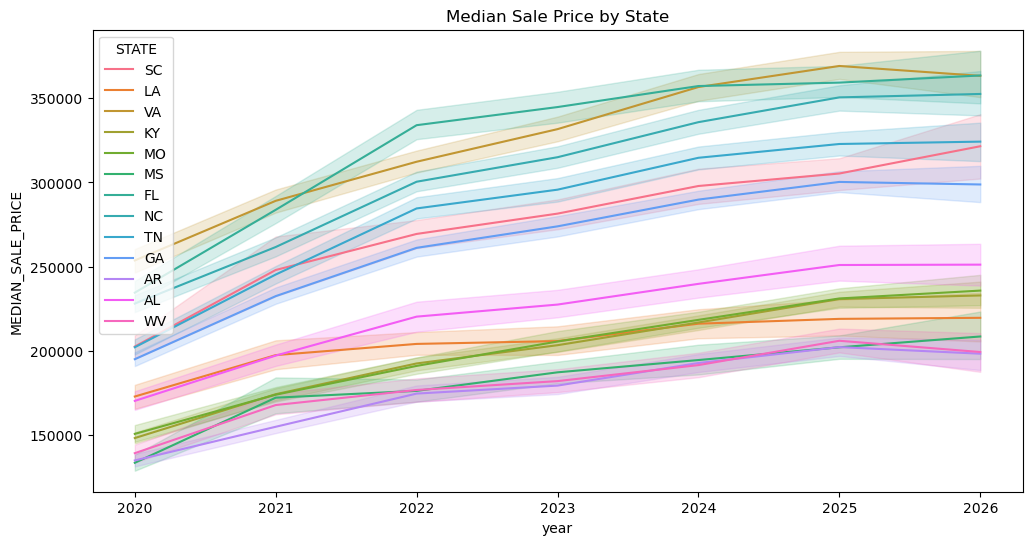

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
df_all['year'] = df_all['year'].astype(str)
# df_all['YEAR_MONTH'] = df_all['YEAR_MONTH'].dt.to_timestamp()

sns.lineplot(
    data=df_all,
    x='year',
    y='MEDIAN_SALE_PRICE',
    hue='STATE'
)
plt.title('Median Sale Price by State')
plt.show()

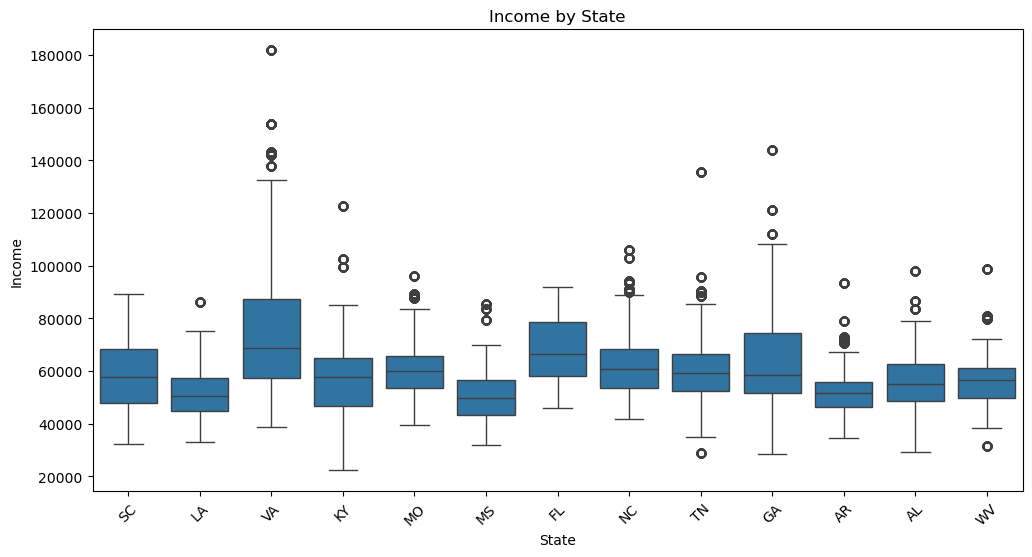

In [81]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_all,
    x='STATE',
    y='Income'
)

plt.title('Income by State')
plt.suptitle('')  
plt.xlabel('State')
plt.ylabel('Income')
plt.xticks(rotation=45)

plt.show()

<Figure size 1200x600 with 0 Axes>

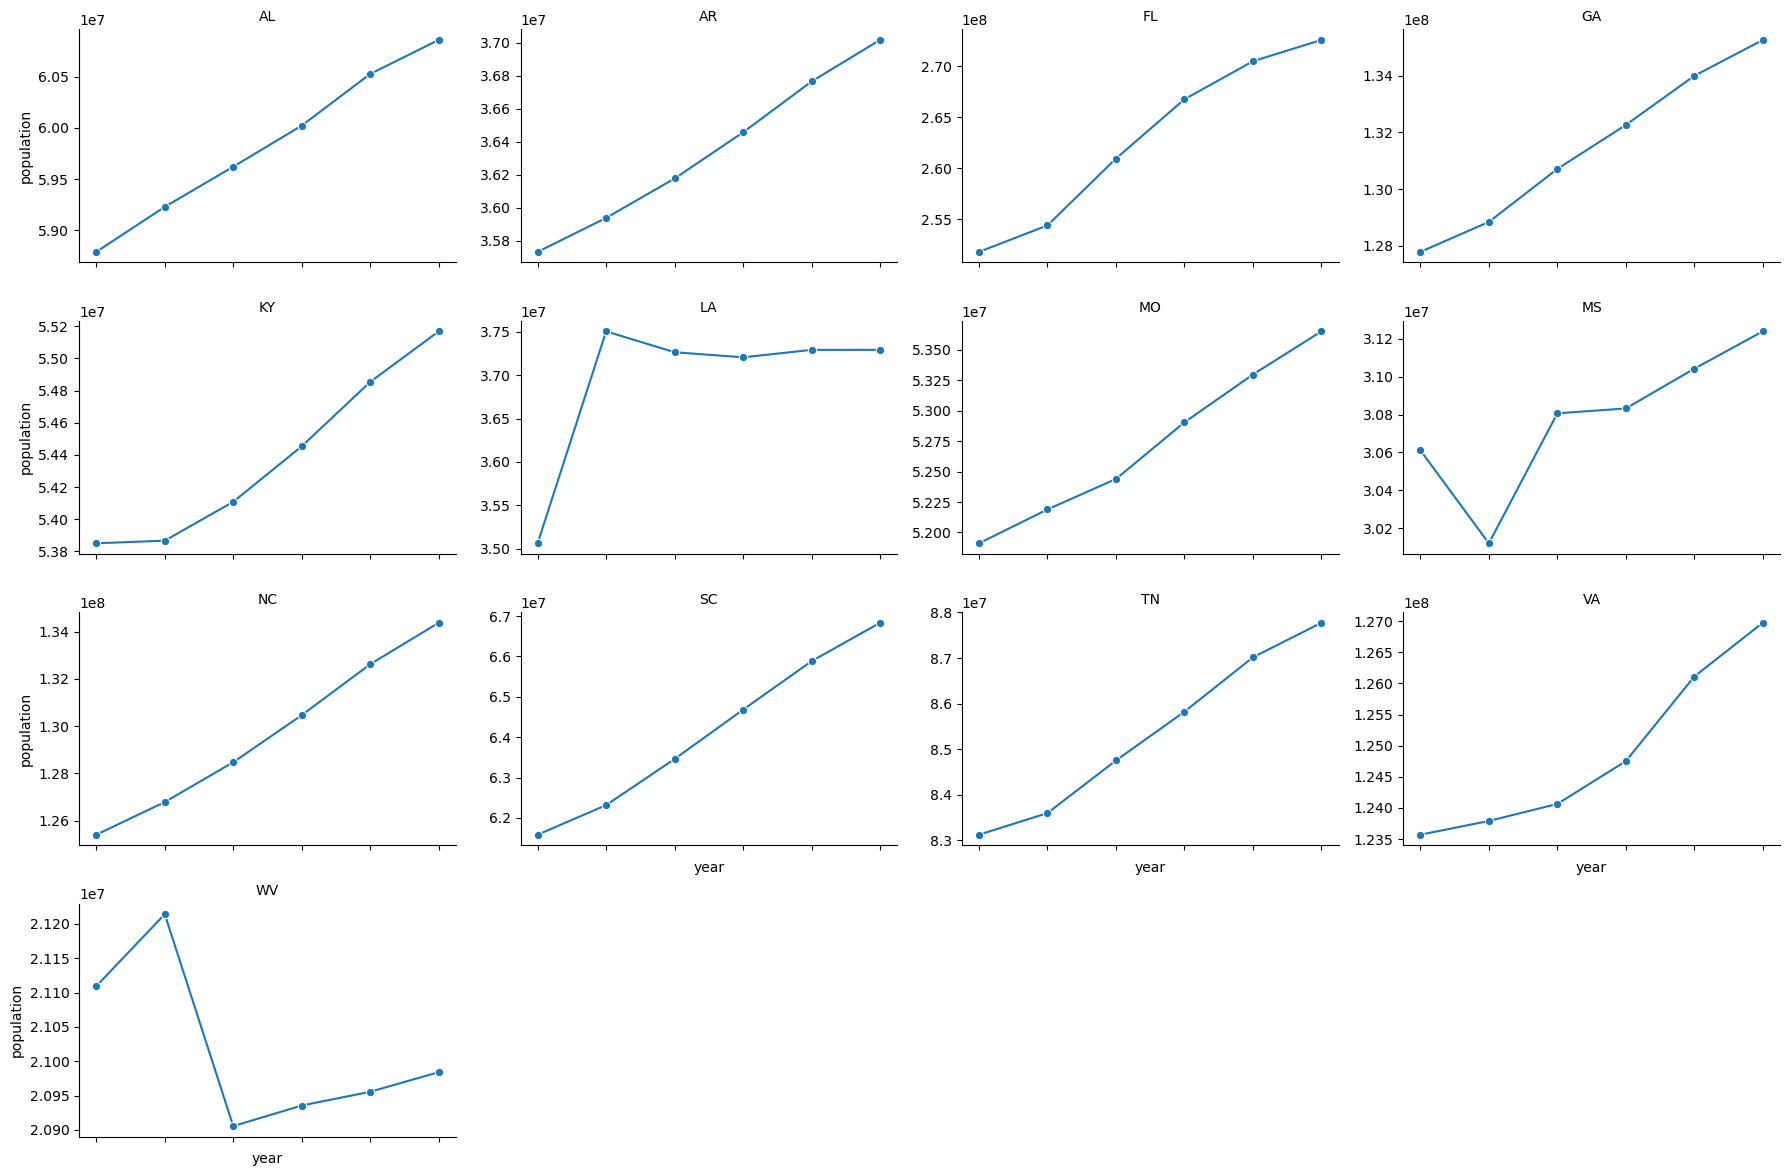

In [82]:
plt.figure(figsize=(12,6))
state_p = df_all[(df_all['year'] >= '2020') & (df_all['year'] <= '2025')].copy()
state_p = state_p.groupby(['STATE','year'])['population'].sum().reset_index()


g = sns.relplot(
    data=state_p,
    x='year',
    y='population',
    kind='line',
    col='STATE',
    col_wrap=4,
    height=3,
    aspect=1.5,
    marker='o',
    facet_kws={'sharey': False}
)


g.set_xticklabels(rotation=45)
g.set_titles("{col_name}") 

plt.show()

In [83]:
df_all.columns

Index(['REGION_NAME', 'REGION_ID', 'YEAR_MONTH',
       'ADJUSTED_AVERAGE_NEW_LISTINGS',
       'AVERAGE_PENDING_SALES_LISTING_UPDATES', 'ADJUSTED_AVERAGE_HOMES_SOLD',
       'MEDIAN_NEW_LISTING_PRICE', 'MEDIAN_SALE_PRICE', 'MEDIAN_DAYS_TO_CLOSE',
       'MEDIAN_NEW_LISTING_PPSF', 'ACTIVE_LISTINGS', 'MEDIAN_DAYS_ON_MARKET',
       'AGE_OF_INVENTORY', 'WEEKS_OF_SUPPLY', 'AVERAGE_SALE_TO_LIST_RATIO',
       'MEDIAN_SALE_PPSF', 'STATE', 'year', 'population', 'Income', 'FIPS',
       'unemployment_rate', 'employment', 'Absorption_rate',
       'months_of_supply'],
      dtype='object')

In [84]:
latest_period = df_all['YEAR_MONTH'].max()

recent_df = df_all[df_all['YEAR_MONTH'] >= latest_period - 11].copy()


county_df = (
    recent_df
    .sort_values('YEAR_MONTH')
    .groupby('REGION_NAME')
    .agg({
    'STATE':'last',
    'Income':'last',
    'MEDIAN_SALE_PRICE':'last',
    'unemployment_rate':'mean',
    'Absorption_rate':'mean',
    'months_of_supply':'mean',
    'AVERAGE_SALE_TO_LIST_RATIO':'mean',
    'MEDIAN_DAYS_ON_MARKET':'mean',
    'ADJUSTED_AVERAGE_HOMES_SOLD':'mean',
    'ACTIVE_LISTINGS':'mean',
    'population':'last',
    'FIPS':'last'
    
}).reset_index()
)

In [85]:
county_df.describe()

,Income,MEDIAN_SALE_PRICE,unemployment_rate,Absorption_rate,months_of_supply,AVERAGE_SALE_TO_LIST_RATIO,MEDIAN_DAYS_ON_MARKET,ADJUSTED_AVERAGE_HOMES_SOLD,ACTIVE_LISTINGS,population
count,1138.000000,1.138000e+03,1138.000000,1138.000000,1138.000000,1138.000000,1138.000000,1138.000000,1138.000000,1.138000e+03
mean,60986.083480,2.838931e+05,4.262685,0.070591,5.553023,0.959373,84.483348,19.464477,418.541064,8.090451e+04
std,17327.773539,1.359922e+05,1.060450,0.080343,2.609555,0.027230,36.167915,45.556361,1216.055578,1.863920e+05
min,22188.000000,5.501000e+03,2.208333,0.007550,0.184758,0.771753,16.447917,1.000000,1.000000,1.691480e+03
25%,50273.500000,1.997938e+05,3.541667,0.042125,3.857425,0.946749,61.843750,1.918312,34.020833,1.423573e+04
50%,57804.000000,2.677927e+05,4.087500,0.053037,5.285964,0.962424,78.232639,4.197875,95.791667,2.669415e+04
75%,67260.250000,3.436281e+05,4.761458,0.071790,6.976417,0.976135,100.469618,14.088542,289.479167,6.383769e+04
max,181765.000000,1.170500e+06,12.537500,1.000000,34.010136,1.218342,441.000000,443.520833,18230.750000,2.822698e+06


In [86]:
county_df['ADJUSTED_AVERAGE_HOMES_SOLD'].describe()

count    1138.000000
mean       19.464477
std        45.556361
min         1.000000
25%         1.918312
50%         4.197875
75%        14.088542
max       443.520833
Name: ADJUSTED_AVERAGE_HOMES_SOLD, dtype: float64

In [87]:
#7050 homes by 2028, so I removed slower markets (Approximately 40% of total county)
county_df = county_df[county_df['ADJUSTED_AVERAGE_HOMES_SOLD']>=3]

In [88]:
county_df

,REGION_NAME,STATE,Income,MEDIAN_SALE_PRICE,unemployment_rate,Absorption_rate,months_of_supply,AVERAGE_SALE_TO_LIST_RATIO,MEDIAN_DAYS_ON_MARKET,ADJUSTED_AVERAGE_HOMES_SOLD,ACTIVE_LISTINGS,population,FIPS
0,"Abbeville County, SC",SC,52935,400000.000,4.995833,0.043077,8.021602,0.953361,92.197917,3.076333,72.000000,24944.243871,45001
1,"Acadia Parish, LA",LA,45562,178925.000,4.191667,0.048315,5.942828,0.952946,88.041667,5.604167,116.333333,56947.870896,22001
2,"Accomack County, VA",VA,58993,363125.000,4.600000,0.032557,8.365790,0.957077,76.781250,8.270833,254.416667,33946.217006,51001
4,"Adair County, MO",MO,61536,200962.500,4.658333,0.058458,5.734432,0.991545,84.781250,5.229167,88.583333,25761.940320,29001
5,"Adams County, MS",MS,43644,197312.500,5.604167,0.027923,11.894366,0.927448,118.989583,3.895833,141.000000,30188.715078,28001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,"Wythe County, VA",VA,57745,220875.000,4.304167,0.046083,7.624767,0.956353,74.909722,4.812417,105.916667,27919.565132,51197
1131,"Yadkin County, NC",NC,62932,286125.000,3.304167,0.060535,4.851906,0.971036,74.479167,4.895833,82.000000,38530.227497,37197
1133,"Yancey County, NC",NC,58709,369500.000,3.729167,0.023097,14.156505,0.947087,119.937500,4.138833,181.916667,19197.341587,37199
1136,"York County, SC",SC,89095,435937.500,4.691667,0.053210,4.600622,0.981244,71.156250,83.666667,1562.583333,311416.216229,45091


In [89]:
cluster_features_ = [
    
    'Income',
    'unemployment_rate',
    'Absorption_rate',
    'months_of_supply',
    'AVERAGE_SALE_TO_LIST_RATIO',
    'MEDIAN_SALE_PRICE',
    'MEDIAN_DAYS_ON_MARKET',
    'ADJUSTED_AVERAGE_HOMES_SOLD'
]

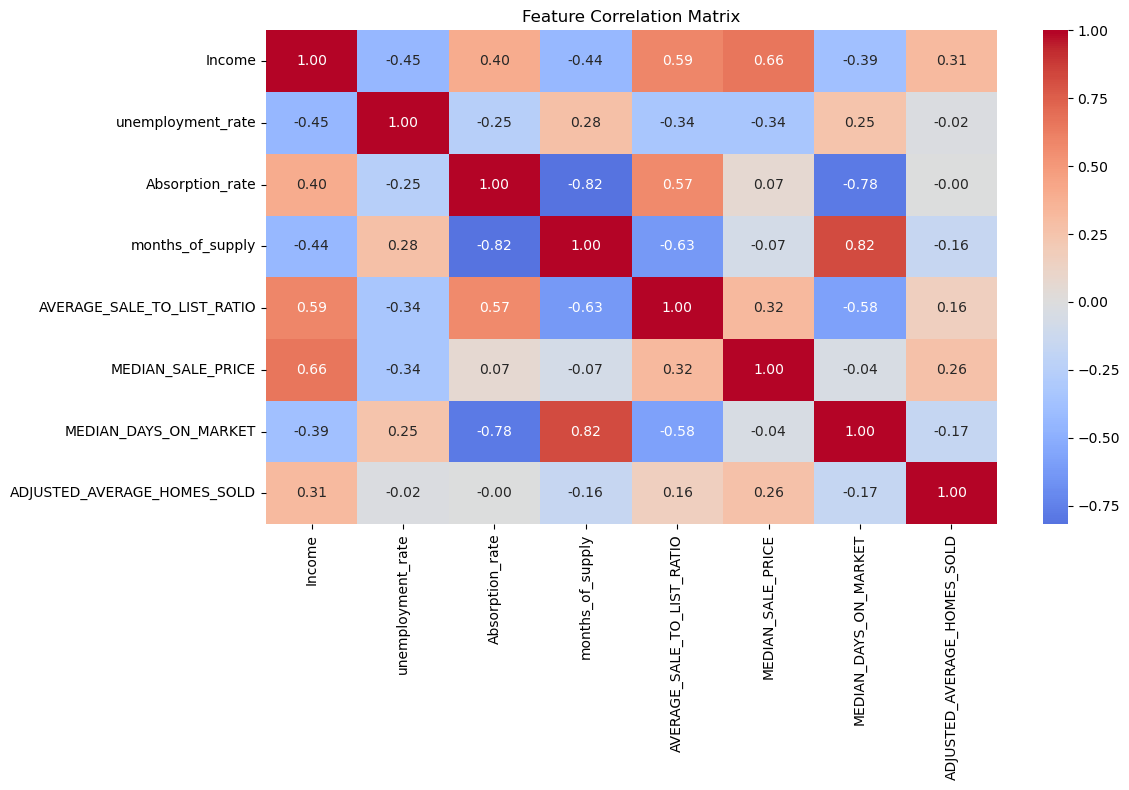

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
# latest = county_df[county_df['YEAR_MONTH'] == county_df['YEAR_MONTH'].max()].copy()

corr = county_df[cluster_features_].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Kmeans 

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

def income_fit(x):
    if 60000 <= x <= 120000:
        return 1.0
    elif x < 60000:
        return max(0, x / 60000)
    else:
        return max(0, 120000 / x)

def price_fit(x):
    if 200000 <= x <= 300000:
        return 1.0
    elif x < 200000:
        return max(0, x / 200000)
    else:
        return max(0, 300000 / x)

The income fit function evaluates whether a county's median household income aligns with Lagom's target customer base. The ideal income range is defined as 60,000–120,000 dollar, which receives a full score of 1.0.

For counties with income below 60,000 dollar, the score decreases proportionally because lower-income markets may have weaker purchasing power. For counties above $120,000, the score also decreases because higher-income markets may indicate less affordability and less alignment with Lagom's target segment.


The price fit function measures how closely a county's median home price matches Lagom's target affordability range. The target price range is defined as 200,000–300,000, where counties receive a score of 1.0.

For markets below 200,000, the score decreases because extremely low prices may indicate weaker demand or less desirable markets. For markets above 300,000, the score decreases as higher prices reduce affordability and move away from Lagom's investment strategy.

In [92]:
#Scales features, runs the elbow method, and prints silhouette scores.
#Returns the scaled array for use in the final fitting step
def evaluate_kmeans(df, features, k_min=2, k_max=10, random_state=42, n_init=20):

    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    inertia = []
    k_range = range(k_min, k_max + 1)
    
    
    for k in k_range:
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            random_state=random_state,
            n_init=n_init
        )
        labels = kmeans.fit_predict(X_scaled)
        inertia.append(kmeans.inertia_)
        
        score = silhouette_score(X_scaled, labels)
        print(f'k = {k}: Silhouette Score = {score:.4f}')
        
    
    plt.figure(figsize=(7, 5))
    plt.plot(k_range, inertia, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.grid(True)
    plt.show()
    
    return X_scaled

In [93]:
#Fits final K-Means model on the scaled data and returns cluster labels.
def assign_clusters(df, X_scaled, n_clusters=3, random_state=42, n_init=20):

    kmeans = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        random_state=random_state,
        n_init=n_init)
    
    return kmeans.fit_predict(X_scaled)

In [94]:
#Visualizes clusters using a 2D PCA projection.
def plot_pca_clusters(X_scaled, cluster_labels):

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap='viridis',
        alpha=0.6)
    
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('K-Means Clusters (PCA Projection)')
    plt.show()

In [95]:

def calculate_market_scores(df, score_features):
    """
    Copies dataframe, runs custom MinMax transformations, applies inversions,
    calculates custom weighted fitness scores, and normalizes final scores to 0-100.
    """
    target_markets = df.copy()
    
    # Scale base scoring features
    scaler = MinMaxScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(target_markets[score_features]),
        columns=score_features,
        index=target_markets.index)
    
    # Apply custom fitness equations
    scaled['Income_Fit'] = target_markets['Income'].apply(income_fit)
    scaled['Price_Fit'] = target_markets['MEDIAN_SALE_PRICE'].apply(price_fit)
    
    # Invert designated negative-direction metrics
    scaled['unemployment_rate'] = 1 - scaled['unemployment_rate']
    scaled['months_of_supply'] = 1 - scaled['months_of_supply']
    
    # Weighted composite equation
    target_markets['Market_Score'] = (
          0.20 * scaled['Absorption_rate']
        + 0.15 * scaled['months_of_supply']
        + 0.15 * scaled['AVERAGE_SALE_TO_LIST_RATIO']
        + 0.15 * scaled['ADJUSTED_AVERAGE_HOMES_SOLD']
        + 0.15 * scaled['Income_Fit']
        + 0.15 * scaled['Price_Fit']
        + 0.05 * scaled['unemployment_rate'])
    
    # Final 0-100 normalization
    target_markets['Market_Score'] = target_markets['Market_Score'] * 100
    target_markets['Market_Score'] = MinMaxScaler(feature_range=(0, 100)).fit_transform(
        target_markets[['Market_Score']])
    
    return target_markets

k = 2: Silhouette Score = 0.2693
k = 3: Silhouette Score = 0.2810
k = 4: Silhouette Score = 0.2226
k = 5: Silhouette Score = 0.2136
k = 6: Silhouette Score = 0.2163
k = 7: Silhouette Score = 0.2196
k = 8: Silhouette Score = 0.2011
k = 9: Silhouette Score = 0.1891
k = 10: Silhouette Score = 0.1952


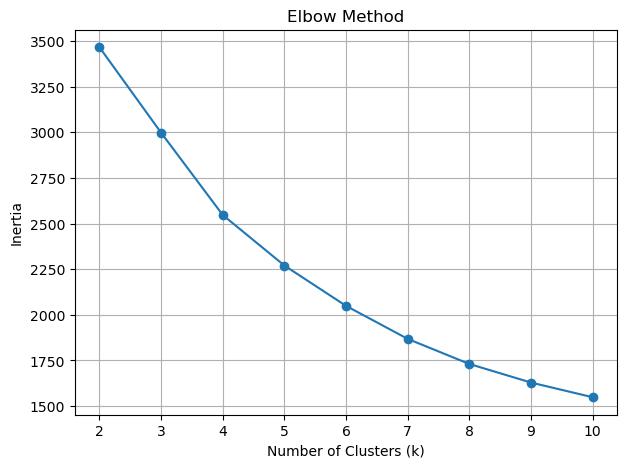

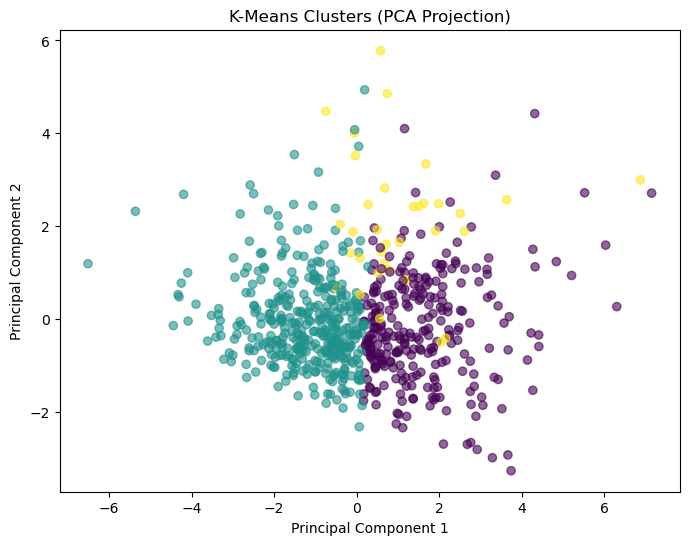

In [96]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

cluster_features = [
    'Income', 'unemployment_rate', 'Absorption_rate', 'months_of_supply',
    'AVERAGE_SALE_TO_LIST_RATIO', 'MEDIAN_SALE_PRICE', 'ADJUSTED_AVERAGE_HOMES_SOLD'
]

score_features = cluster_features.copy() 
X_scaled = evaluate_kmeans(county_df, cluster_features)
county_df['Cluster'] = assign_clusters(county_df, X_scaled, n_clusters=3)
plot_pca_clusters(X_scaled, county_df['Cluster'])
final_target_markets = calculate_market_scores(county_df, score_features)

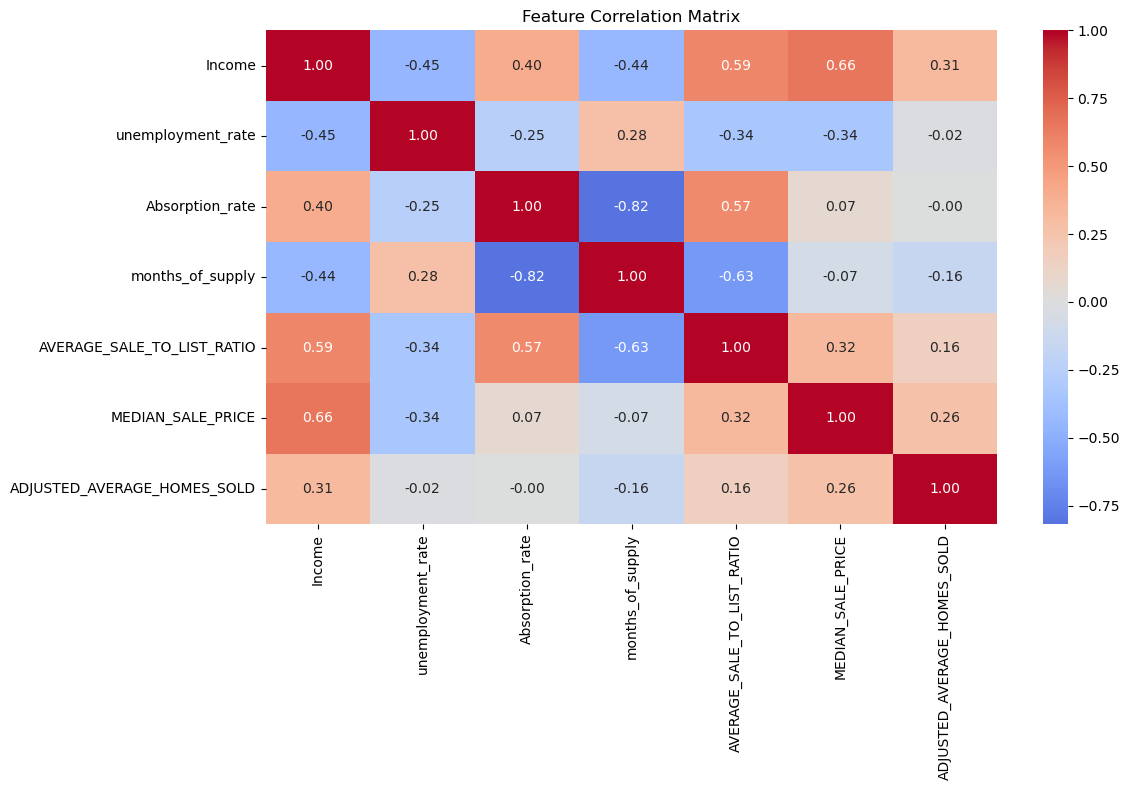

In [97]:
corrs = county_df[cluster_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corrs, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


Absorption Rate and Months of Supply exhibited a strong inverse correlation because both measure housing market liquidity from different perspectives. Despite this relationship, both variables were retained because they capture distinct business concepts: demand intensity and inventory availability, which are commonly used together in housing market analysis.

In [98]:
target_markets = calculate_market_scores(county_df, score_features)
target_markets = target_markets.sort_values('Market_Score',ascending=False)

target_markets

,REGION_NAME,STATE,Income,MEDIAN_SALE_PRICE,unemployment_rate,Absorption_rate,months_of_supply,AVERAGE_SALE_TO_LIST_RATIO,MEDIAN_DAYS_ON_MARKET,ADJUSTED_AVERAGE_HOMES_SOLD,ACTIVE_LISTINGS,population,FIPS,Cluster,Market_Score
18,"Amelia County, VA",VA,76717,292712.5,3.550000,0.143524,2.269202,0.995255,21.243055,3.506917,25.416667,13701.607453,51007,0,100.000000
238,"Cole County, MO",MO,74876,286587.5,3.125000,0.132731,2.004755,0.994236,16.447917,16.083333,121.833333,78154.371008,29051,0,98.308103
241,"Colonial Heights, VA",VA,76505,281850.0,3.633333,0.131434,2.298842,0.990720,33.489583,4.166667,32.333333,18848.158774,51570,0,94.819312
538,"Jefferson County, MO",MO,82851,296837.5,3.591667,0.105682,2.313810,1.008046,25.197917,51.166667,483.000000,234311.370490,29099,0,92.158111
1088,"Waynesboro, VA",VA,59994,312600.0,3.208333,0.124495,2.596620,0.991927,33.239583,7.020833,56.750000,24278.371453,51820,0,91.776719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,"Van Buren County, AR",AR,50354,150375.0,5.237500,0.023697,13.444419,0.936785,139.190972,3.888833,161.333333,16321.408707,05141,1,11.649155
993,"Swain County, NC",NC,52349,524250.0,3.512500,0.024378,14.239775,0.945222,126.986111,3.347167,134.333333,14008.700459,37173,1,10.455816
279,"Dallas County, AL",AL,35627,131625.0,4.441667,0.030160,10.243136,0.918712,155.958333,3.104167,102.333333,34598.657205,01047,1,6.727804
1075,"Washington County, MS",MS,42165,266112.5,5.104167,0.033269,10.388598,0.814187,129.402778,3.361083,102.166667,39705.638810,28151,1,4.494873


In [99]:
cluster_summary = county_df.groupby('Cluster')[cluster_features].median().round(2)

cluster_summary.T

Cluster,0,1,2
Income,76611.00,56713.00,77024.00
unemployment_rate,3.52,4.30,4.35
Absorption_rate,0.06,0.04,0.04
months_of_supply,4.31,6.99,5.33
AVERAGE_SALE_TO_LIST_RATIO,0.98,0.96,0.97
MEDIAN_SALE_PRICE,340504.38,258856.25,394125.00
ADJUSTED_AVERAGE_HOMES_SOLD,22.36,6.00,198.50


In [100]:
target_markets['Tier'] = ''
target_markets.loc[target_markets['Cluster']==0, 'Tier'] ='Tier 1' #Balanced suburban markets with strong demand and moderate prices
target_markets.loc[target_markets['Cluster']==1, 'Tier'] ='Tier 2' #Smaller, slower-growing markets with lower transaction volume
target_markets.loc[target_markets['Cluster']==2, 'Tier'] ='Watch List' #Large metropolitan markets with high transaction volume and higher prices

In [101]:
county_df[['Income','MEDIAN_SALE_PRICE','unemployment_rate','Absorption_rate','months_of_supply','AVERAGE_SALE_TO_LIST_RATIO','ADJUSTED_AVERAGE_HOMES_SOLD']].describe()

,Income,MEDIAN_SALE_PRICE,unemployment_rate,Absorption_rate,months_of_supply,AVERAGE_SALE_TO_LIST_RATIO,ADJUSTED_AVERAGE_HOMES_SOLD
count,689.000000,6.890000e+02,689.000000,689.000000,689.000000,689.000000,689.000000
mean,67260.622642,3.218408e+05,4.007450,0.052193,6.088924,0.967974,30.978146
std,17687.802997,1.278418e+05,0.820553,0.018442,2.282345,0.017766,55.615924
min,35627.000000,1.116250e+05,2.208333,0.016800,1.994527,0.814187,3.006917
25%,55487.000000,2.402250e+05,3.420833,0.040203,4.581073,0.958044,5.118000
50%,62873.000000,2.968375e+05,3.908333,0.048527,5.775342,0.969894,9.854167
75%,75057.000000,3.724725e+05,4.541667,0.060220,7.392222,0.979455,29.333333
max,181765.000000,1.143500e+06,7.666667,0.143524,21.411003,1.022148,443.520833


In [102]:
def classify_market(row):
    
    strong = 0

    #Hard rule
    # Income
    if 60000 <= row['Income'] <= 120000:
        strong += 1
    # Hard rule
    # Home Price
    if 200000 <= row['MEDIAN_SALE_PRICE'] <= 300000:
        strong += 1

    # A bit aggressive here. Higher than the third quartile
    # Absorption Rate
    if row['Absorption_rate'] >= 0.08:
        strong += 1
        
    # The lower, the better. Seller's market
    # Months of Supply
    if row['months_of_supply'] <= 3:
        strong += 1

    # Sale-to-List Ratio
    if row['AVERAGE_SALE_TO_LIST_RATIO'] >= 0.95:
        strong += 1

    # Unemployment
    if row['unemployment_rate'] <= 4:
        strong += 1

    

    # ----- Business Rules -----

    if row['Cluster'] == 0:            # Balanced suburban markets
        
        if row['ADJUSTED_AVERAGE_HOMES_SOLD'] < 15:
            return "Insufficient Scale"
        
        elif strong >= 5:
            return "High Fit"
        elif strong >= 4:
            return "Moderate Fit"
        else:
            return "Not Recommended"

    elif row['Cluster'] == 1:          # Smaller/slower markets
        
        if row['ADJUSTED_AVERAGE_HOMES_SOLD'] < 15:
            return "Insufficient Scale"
        elif strong >= 4:
            return "High Fit"
        elif strong >=3:
            return 'Moderate Fit'
        else:
            return "Not Recommended"

    else:                             # Large metro markets
        
        if row['ADJUSTED_AVERAGE_HOMES_SOLD'] < 15:
            return "Insufficient Scale"
        elif strong >= 4:
            return 'Future Expansion'
        else:
            
            return "Watch List"

In [103]:
target_markets['Qualified'] = target_markets.apply(classify_market, axis=1)

In [104]:
target_markets.groupby('Tier')['Qualified'].value_counts()

Tier        Qualified         
Tier 1      Not Recommended       124
            Insufficient Scale     99
            Moderate Fit           26
            High Fit               21
Tier 2      Insufficient Scale    314
            Not Recommended        43
            Moderate Fit           21
            High Fit                6
Watch List  Watch List             33
            Future Expansion        2
Name: count, dtype: int64

In [105]:
print(target_markets.groupby(['Tier','Qualified']).agg(Qualified_count = ('Qualified','count'), Avg_market_score = ( 'Market_Score','mean')))

                               Qualified_count  Avg_market_score
Tier       Qualified                                            
Tier 1     High Fit                         21         81.412609
           Insufficient Scale               99         62.249607
           Moderate Fit                     26         68.378831
           Not Recommended                 124         59.075029
Tier 2     High Fit                          6         55.505982
           Insufficient Scale              314         41.788458
           Moderate Fit                     21         51.524090
           Not Recommended                  43         46.731385
Watch List Future Expansion                  2         81.580733
           Watch List                       33         62.606600


In [106]:
top10 = target_markets[target_markets['Qualified']=='High Fit'][['REGION_NAME','Income','MEDIAN_SALE_PRICE','Absorption_rate','AVERAGE_SALE_TO_LIST_RATIO','ADJUSTED_AVERAGE_HOMES_SOLD','Market_Score','Qualified']].head(10).reset_index(drop=True)

In [107]:
top10

,REGION_NAME,Income,MEDIAN_SALE_PRICE,Absorption_rate,AVERAGE_SALE_TO_LIST_RATIO,ADJUSTED_AVERAGE_HOMES_SOLD,Market_Score,Qualified
0,"Cole County, MO",74876,286587.50,0.132731,0.994236,16.083333,98.308103,High Fit
1,"Jefferson County, MO",82851,296837.50,0.105682,1.008046,51.166667,92.158111,High Fit
2,"Henrico County, VA",88783,400375.00,0.120245,1.001941,79.875000,90.835000,High Fit
3,"Kenton County, KY",80548,291000.00,0.111278,0.984785,43.666667,89.567817,High Fit
4,"Virginia Beach, VA",92968,396475.00,0.110070,0.996402,114.541667,89.299406,High Fit
5,"Clay County, MO",88468,332112.50,0.101968,0.996496,77.562500,87.559347,High Fit
6,"Daviess County, KY",68214,234987.50,0.111974,0.976899,23.562500,86.528104,High Fit
7,"Chesterfield County, VA",101931,422350.00,0.105760,1.002834,107.375000,86.255939,High Fit
8,"Campbell County, KY",77567,261625.00,0.098236,0.979134,24.041667,81.901022,High Fit
9,"Richmond city,VA",66304,405179.75,0.103322,1.003586,51.437500,81.057705,High Fit


In [ ]:
target_markets[['REGION_NAME','']]

In [108]:
top10_market_score = target_markets[['REGION_NAME','Market_Score']].head(10).reset_index(drop=True)
top10_market_score

,REGION_NAME,Market_Score
0,"Amelia County, VA",100.000000
1,"Cole County, MO",98.308103
2,"Colonial Heights, VA",94.819312
3,"Jefferson County, MO",92.158111
4,"Waynesboro, VA",91.776719
5,"Henrico County, VA",90.835000
6,"Staunton, VA",89.859294
7,"Kenton County, KY",89.567817
8,"Virginia Beach, VA",89.299406
9,"Jackson County, MO",88.722883


In [109]:
print(top10[['REGION_NAME','Income','MEDIAN_SALE_PRICE','Market_Score','Qualified']])

               REGION_NAME  Income  MEDIAN_SALE_PRICE  Market_Score Qualified
0          Cole County, MO   74876          286587.50     98.308103  High Fit
1     Jefferson County, MO   82851          296837.50     92.158111  High Fit
2       Henrico County, VA   88783          400375.00     90.835000  High Fit
3        Kenton County, KY   80548          291000.00     89.567817  High Fit
4       Virginia Beach, VA   92968          396475.00     89.299406  High Fit
5          Clay County, MO   88468          332112.50     87.559347  High Fit
6       Daviess County, KY   68214          234987.50     86.528104  High Fit
7  Chesterfield County, VA  101931          422350.00     86.255939  High Fit
8      Campbell County, KY   77567          261625.00     81.901022  High Fit
9         Richmond city,VA   66304          405179.75     81.057705  High Fit


In [110]:
#target_markets.to_csv("lagom_market_prioritization_final.csv", index=False)